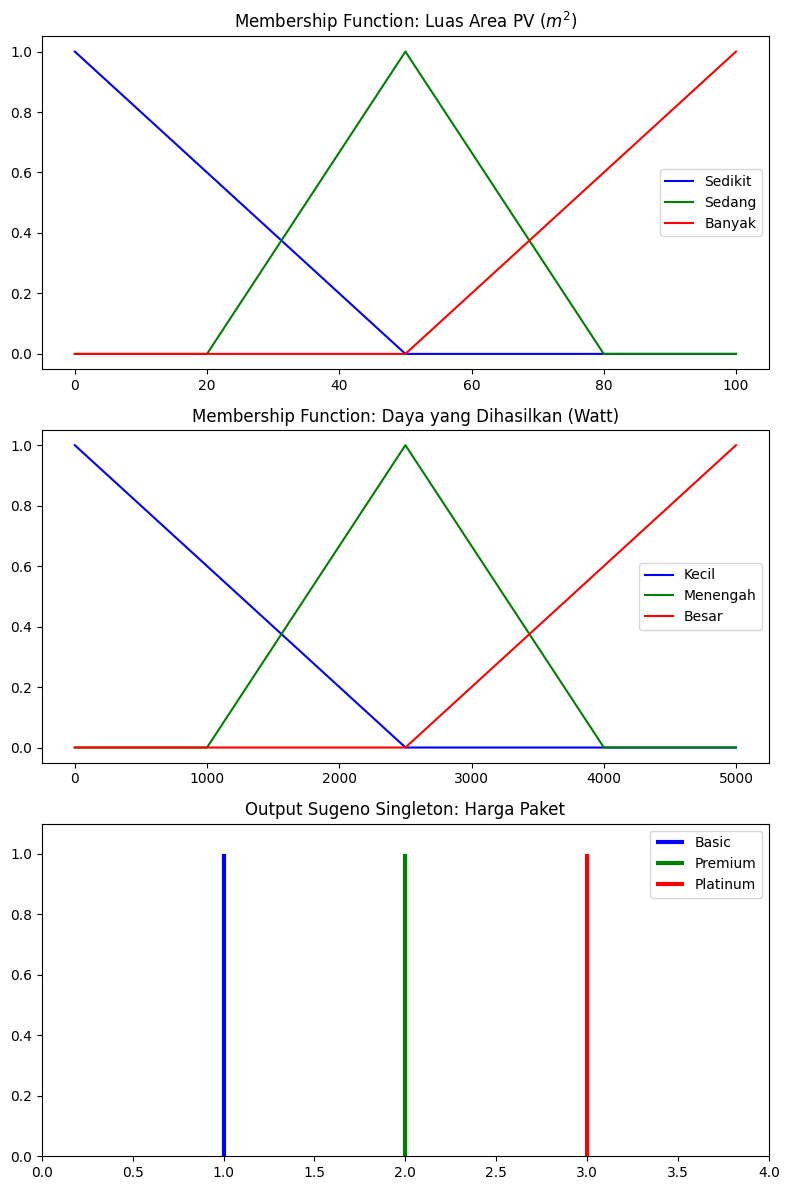

--- HASIL SIMULASI ---
Luas Area PV: 75 m2
Daya yang Dihasilkan: 3000 Watt
Rekomendasi Harga Paket (kategori): 2.32
Direkomendasikan Paket: Premium (Sekitar Rp 35 Juta)


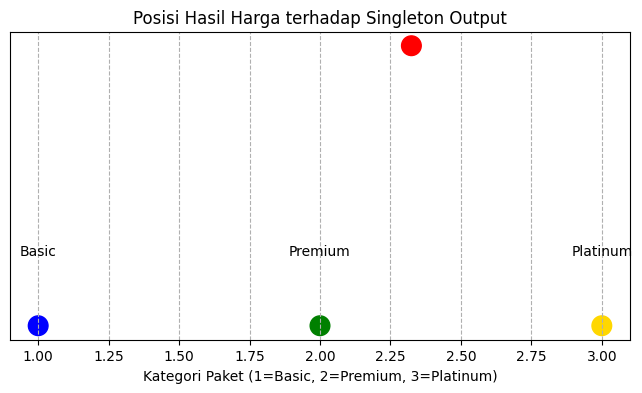

In [14]:
!pip install scikit-fuzzy
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# --- 1. Definisi Semesta Pembicaraan (Universe) ---
# Luas Area (0-100 m2), Daya (0-5000 Watt), Output (0-3 untuk kategori)
luas_area = ctrl.Antecedent(np.arange(0, 101, 1), 'luas_area')
daya_hasil = ctrl.Antecedent(np.arange(0, 5001, 1), 'daya_hasil')
harga_paket = ctrl.Consequent(np.arange(0, 4, 0.1), 'harga_paket')

# --- 2. Membership Function (MF) Input ---
# MF Luas Area PV
luas_area['sedikit'] = fuzzy.trimf(luas_area.universe, [0, 0, 50])
luas_area['sedang'] = fuzzy.trimf(luas_area.universe, [20, 50, 80])
luas_area['banyak'] = fuzzy.trimf(luas_area.universe, [50, 100, 100])

# MF Daya yang dihasilkan
daya_hasil['kecil'] = fuzzy.trimf(daya_hasil.universe, [0, 0, 2500])
daya_hasil['menengah'] = fuzzy.trimf(daya_hasil.universe, [1000, 2500, 4000])
daya_hasil['besar'] = fuzzy.trimf(daya_hasil.universe, [2500, 5000, 5000])

# --- 3. Output Singleton (Sugeno Orde-0) ---
# Nilai konstanta: Basic=1, Premium=2, Platinum=3
# Menggunakan trimf sempit untuk mensimulasikan singleton pada plot
harga_paket['Basic'] = fuzzy.trimf(harga_paket.universe, [0.9, 1, 1.1])
harga_paket['Premium'] = fuzzy.trimf(harga_paket.universe, [1.9, 2, 2.1])
harga_paket['Platinum'] = fuzzy.trimf(harga_paket.universe, [2.9, 3, 3.1])

# --- 4. Aturan (Rules) ---
rule1 = ctrl.Rule(luas_area['sedikit'] & daya_hasil['kecil'], harga_paket['Basic'])
rule2 = ctrl.Rule(luas_area['sedikit'] & daya_hasil['menengah'], harga_paket['Premium'])
rule3 = ctrl.Rule(luas_area['sedikit'] & daya_hasil['besar'], harga_paket['Platinum'])
rule4 = ctrl.Rule(luas_area['sedang'] & daya_hasil['kecil'], harga_paket['Basic'])
rule5 = ctrl.Rule(luas_area['sedang'] & daya_hasil['menengah'], harga_paket['Premium'])
rule6 = ctrl.Rule(luas_area['sedang'] & daya_hasil['besar'], harga_paket['Platinum'])
rule7 = ctrl.Rule(luas_area['banyak'] & daya_hasil['kecil'], harga_paket['Basic'])
rule8 = ctrl.Rule(luas_area['banyak'] & daya_hasil['menengah'], harga_paket['Premium'])
rule9 = ctrl.Rule(luas_area['banyak'] & daya_hasil['besar'], harga_paket['Platinum'])

# --- Create Control System ---
harga_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
harga_simulasi = ctrl.ControlSystemSimulation(harga_ctrl)

def hitung_fis(input_luas_area, input_daya_hasil):
    harga_simulasi.input['luas_area'] = input_luas_area
    harga_simulasi.input['daya_hasil'] = input_daya_hasil
    harga_simulasi.compute()
    return harga_simulasi.output['harga_paket']

# --- 5. Visualisasi Grafik ---
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, figsize=(8, 12))

# Plot Luas Area
ax0.plot(luas_area.universe, fuzzy.trimf(luas_area.universe, [0, 0, 50]), 'b', linewidth=1.5, label='Sedikit')
ax0.plot(luas_area.universe, fuzzy.trimf(luas_area.universe, [20, 50, 80]), 'g', linewidth=1.5, label='Sedang')
ax0.plot(luas_area.universe, fuzzy.trimf(luas_area.universe, [50, 100, 100]), 'r', linewidth=1.5, label='Banyak')
ax0.set_title('Membership Function: Luas Area PV ($m^2$)')
ax0.legend()

# Plot Daya Hasil
ax1.plot(daya_hasil.universe, fuzzy.trimf(daya_hasil.universe, [0, 0, 2500]), 'b', linewidth=1.5, label='Kecil')
ax1.plot(daya_hasil.universe, fuzzy.trimf(daya_hasil.universe, [1000, 2500, 4000]), 'g', linewidth=1.5, label='Menengah')
ax1.plot(daya_hasil.universe, fuzzy.trimf(daya_hasil.universe, [2500, 5000, 5000]), 'r', linewidth=1.5, label='Besar')
ax1.set_title('Membership Function: Daya yang Dihasilkan (Watt)')
ax1.legend()

# Plot Output (Sugeno Singletons)
ax2.vlines(1, 0, 1, label='Basic', colors='b', linestyles='solid', linewidth=3)
ax2.vlines(2, 0, 1, label='Premium', colors='g', linestyles='solid', linewidth=3)
ax2.vlines(3, 0, 1, label='Platinum', colors='r', linestyles='solid', linewidth=3)
ax2.set_title('Output Sugeno Singleton: Harga Paket')
ax2.set_ylim(0, 1.1)
ax2.set_xlim(0, 4)
ax2.legend()

plt.tight_layout()
plt.show()

# --- 6. Simulasi Perhitungan ---
luas_area_input = 75
daya_hasil_input = 3000 # Example: 3000 Watt for simulation
hasil = hitung_fis(luas_area_input, daya_hasil_input)

print(f"--- HASIL SIMULASI ---")
print(f"Luas Area PV: {luas_area_input} m2")
print(f"Daya yang Dihasilkan: {daya_hasil_input} Watt")
print(f"Rekomendasi Harga Paket (kategori): {hasil:.2f}")

# Map output category to a descriptive label and an approximate price in Million Rp
if hasil < 1.5:
    paket_label = "Basic"
    harga_juta = 15 # Example price for Basic
elif hasil < 2.5:
    paket_label = "Premium"
    harga_juta = 35 # Example price for Premium
else:
    paket_label = "Platinum"
    harga_juta = 60 # Example price for Platinum

print(f"Direkomendasikan Paket: {paket_label} (Sekitar Rp {harga_juta} Juta)")

labels = ['Basic', 'Premium', 'Platinum', 'Hasil Simulasi']
values = [1, 2, 3, hasil] # Use the numerical categories for output plot
colors = ['blue', 'green', 'gold', 'red']

# Convert values to Juta Rp for plotting against a price axis, if desired
# For consistent visualization with original singletons, stick to categories 1, 2, 3

plt.figure(figsize=(8, 4))
plt.scatter(values, [1, 1, 1, 1.2], c=colors, s=200)
for i, txt in enumerate(labels):
    plt.annotate(txt, (values[i], 1.05 if i != 3 else 1.25), ha='center')
plt.title("Posisi Hasil Harga terhadap Singleton Output")
plt.xlabel("Kategori Paket (1=Basic, 2=Premium, 3=Platinum)")
plt.yticks([])
plt.grid(True, axis='x', linestyle='--')
plt.show()
